# Task 1: Data Exploration and Insights (15%)
Task Description
Analyze the AG News dataset to understand its structure and characteristics.
Suggested analyses:

- Class distribution
- Average and median text length (overall and per class)
- Most frequent words per class
- Word clouds per class
- Distribution of n-gram frequencies
-  …

Please don’t limit yourself to these examples and try to summarize the data with numbers and
graphs. Please highlight some of the most important findings in your report.

---
Deliverable:

- Summarize key findings and observations in your report
- Highlight patterns that may influence modeling choices

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams

Analyze class distribution

In [5]:
def analyze_class_distribution(file_name):
    """
        train.csv and test.csv has n piece of data
        each piece of data belongs to a certain class, which is represented as 1, 2, 3, 4

        1 calculate each class has how many piece of data, N_i, i ∈ 1,2,3,4 is noted as result
        2 N_i / Total : percentage of each class
        3 plot the result as bar diagram

    """
    df = pd.read_csv(file_name)
    class_lst = df["Class Index"].to_list()

    abs_accumulated_class = dict()
    for i in class_lst:
        k = abs_accumulated_class.keys()
        if i in k:
            abs_accumulated_class[i] += 1
        else:
            abs_accumulated_class[i] = 1
    relevant_accumulated_class = abs_accumulated_class.copy()

    size_class = len(class_lst)
    for key, values in relevant_accumulated_class.items():
        relevant_accumulated_class[key] = relevant_accumulated_class[key] / size_class

    return relevant_accumulated_class,abs_accumulated_class

def visulize_relevant_class_distribution(X, file_name):
    # plot the result
    plt.figure(figsize=(3, 3))
    bars = plt.bar(
        X.keys(),
        X.values()
    )

    max_val = max(X.values())
    plt.ylim(0, max_val * 1.25)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, # put text at middle
            height + max_val * 0.03,     # vertical offset
            f"{height:.2f}",  # content of the text, keep 2 decimal
            ha="center",   # horizonal alignment
            va="bottom",   # vertical alignment
            fontsize=8,
            color="black"
        )

    plt.text(
        0.5, -0.25,
        "Discovery: All classes have equal proportion (25%)",
        ha="center",
        transform=plt.gca().transAxes,
        color = "red"
    )
    plt.xlabel(f"Data of {file_name}")
    plt.ylabel("Proportion")
    plt.title(f"Class Distribution of {file_name}")

    plt.show()


def run_t1_analyze_class_distribution():
    paths = ["train.csv","test.csv"]
    for p in paths:
        relevant, _ = analyze_class_distribution(p)
        visulize_relevant_class_distribution(relevant, p)

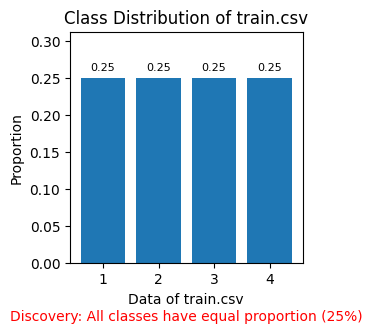

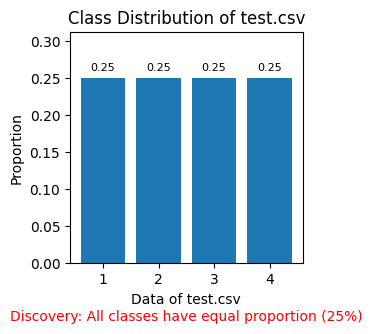

In [6]:
run_t1_analyze_class_distribution()

Analyze Average and median text length (overall and per class)

In [7]:

def analyse_text_length(file_path):
    """ 
    Text Length is in the column "Description", what you need to do is to 
    1) calculate the length of description of each piece of data,
    2) sum up the length
    3) divide the summed up length with the length of the dataset
    4) calculate the median of the text length, median means
        if len is odd, then median is at the floor(len/2) + 1
        if len is even, then median is at len/2
    5) return the ave length and the median length as the return value

    Parameters:
        file_path: the path of the file which need to be calculated,e.g. train.csv
    Returns:
        ave_len: the average length of each piece of data
        median_len: the median length of each piece of data

    """

    df = pd.read_csv(file_path)
    descriptions = df["Description"].tolist()
    l = len(descriptions)
    description_len = np.array([len(x) for x in descriptions])
    sum_up_description_len = np.sum(description_len)
    median_index = int(np.floor(l/2))
    ave_len = round(sum_up_description_len / l,2)
    median_len = len(descriptions[median_index])
    # print(ave_len)
    # print(median_len)

    return ave_len,median_len


def run_analyse_text_length():
    paths = ["train.csv","test.csv"]
    for p in paths:
        ave, median = analyse_text_length(p)
        print("file name: ", p, "\n","average text length: ", ave, "\n","median text length: ", median)



In [8]:
print("Here is the discovery of text length analyse")
run_analyse_text_length()

Here is the discovery of text length analyse
file name:  train.csv 
 average text length:  193.39 
 median text length:  132
file name:  test.csv 
 average text length:  192.41 
 median text length:  154


Analyze Most frequent words per class

In [9]:
def analyse_most_frequent_word(file_path):
    """ 
    You have to concatenate the Title and Description, then do analysis.
    how to know which word is most frequent in a class?
    1) collect data of same class into one collection
    2) in each collection of data, count its words frequency, then find the most frequent value
    3) visualize/summarize the result

    I don't know how to calculat them in a smart way
    how to know how many classes there are in the datasets?
    how to collect data by class?

    discovery:
        the most commom word is "the" in each class
    """

    df = pd.read_csv(file_path)
    df["text"] = df["Title"] + " " + df["Description"]
    class_collect = dict()

    ind_max = df.index.max()
    i = 0
    while i <= ind_max :
        dt_class = df["Class Index"][i]
        dt_text = df["text"][i]
        keys = class_collect.keys()
        if(dt_class in keys):
            class_collect[dt_class] = class_collect[dt_class] + " " + dt_text
        else:
            class_collect[dt_class] = dt_text
        i+=1

    frequency_collect = dict()
    for key, value in class_collect.items(): # tuple ("word", frequency)
        c = Counter(value.split()).most_common()[0]
        frequency_collect[key] = c

    for k,v in frequency_collect.items():
        print(k,v)
    


In [10]:
print("result of train.csv")
analyse_most_frequent_word("train.csv")
print("result of test.csv")
analyse_most_frequent_word("test.csv")
print(f"Discovery: the most commom word in the file train and test is \" the \" in each class")

result of train.csv
3 ('the', 37964)
4 ('the', 40705)
2 ('the', 56380)
1 ('the', 42476)
result of test.csv
3 ('the', 2497)
4 ('the', 2536)
2 ('the', 3563)
1 ('the', 2638)
Discovery: the most commom word in the file train and test is " the " in each class


Analyze Word clouds per class

In [11]:
def get_text_collection_by_class(file_path):
    df = pd.read_csv(file_path)
    df["text"] = df["Title"] + " " + df["Description"]
    class_collect = dict()

    ind_max = df.index.max()
    i = 0
    while i <= ind_max :
        dt_class = df["Class Index"][i]
        dt_text = df["text"][i]
        keys = class_collect.keys()
        if(dt_class in keys):
            class_collect[dt_class] = class_collect[dt_class] + " " + dt_text
        else:
            class_collect[dt_class] = dt_text
        i+=1
    return class_collect

def draw_word_could(text_collect,title):
    print(f"word cloud of {title} dataset",title)
    for key, value in text_collect.items():
        wc = WordCloud(background_color="white").generate(value)
        print("class: ", key)
        plt.imshow(wc)
        plt.axis("off")
        plt.show()

word cloud of train dataset train
class:  3


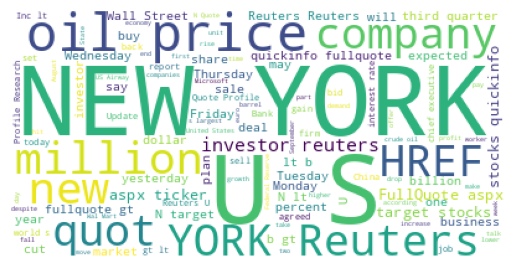

class:  4


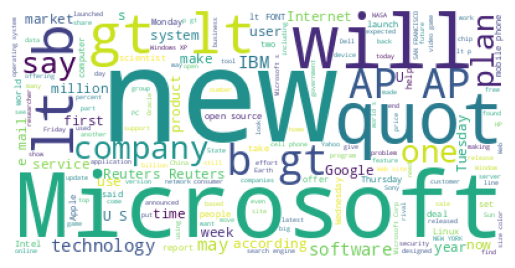

class:  2


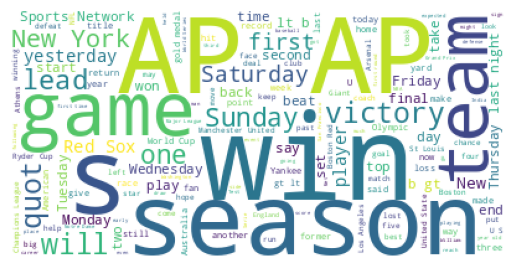

class:  1


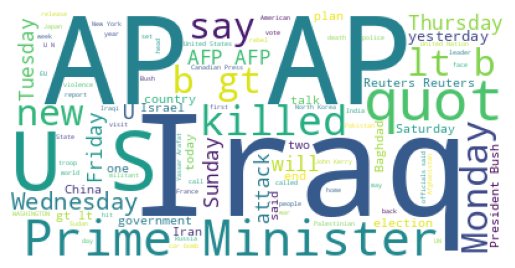



word cloud of test dataset test
class:  3


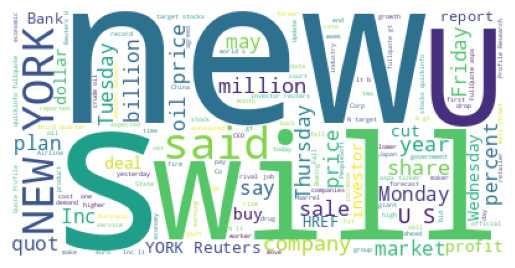

class:  4


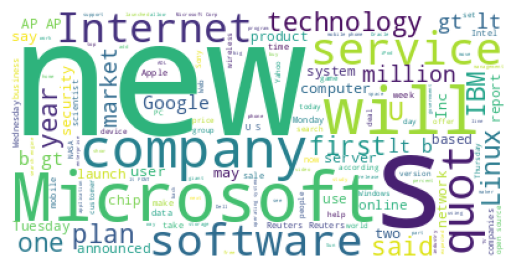

class:  2


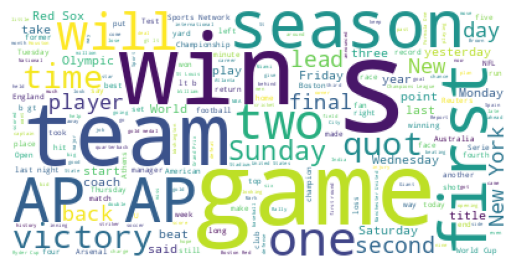

class:  1


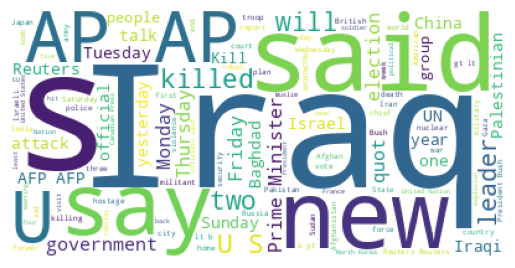

In [12]:
train_dt_text_collect = get_text_collection_by_class("train.csv")
test_dt_text_collect = get_text_collection_by_class("test.csv")

draw_word_could(train_dt_text_collect,"train")
print("\n")
draw_word_could(test_dt_text_collect,"test")

Analyze Distribution of n-gram frequencies

In [13]:

""" 
1) generate n-grams
2) calculate n-grams' frequency
3) calculate its frequency's distribution

in the task above, we already have train_dt_text_collect, and test_dt_text_collect,
they have collected text(title+description) by class


what means distribution analyse
    - visualize distribution
    - categorize the distribution
    - statistische Merkmale

"""

def generate_ngram(n:int, token_list:list):
    """ 
    parameters:
        n: n gram's n
        tocken_list: a list of tocken. On this list we should apply ngram
    example:
        input: 
            n: 2
            tocken_list: ["Venezuelans", "Vote", "Early","in", "Referendum"]
        output: [('Venezuelans', 'Vote'), ('Vote', 'Early'), ('Early', 'in'), ('in', 'Referendum')]
    """

    return list(ngrams(token_list,n))
    

def ngram_frequency(n_grams_tocken_lst):
    r = Counter(n_grams_tocken_lst)
    return r

def topk_frequent_ngram(ngram_freq, k):
    return ngram_freq.most_common(k)

def visualize_ngram_distribution(ngram_freq,title):
    freqs = list(ngram_freq.values())
    freqs.sort(reverse=True)
    plt.figure(figsize=(7,2))
    plt.plot(freqs)
    title = "class: " + str(title)
    plt.title(title)
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    

def run_ngram_distribution_analyse(dt_text_collect,n):
    for key, value in dt_text_collect.items():
        ngrams = generate_ngram(n,list(value.split()))
        freqs = ngram_frequency(ngrams)
        visualize_ngram_distribution(freqs,key)


Discovery: the ngram frequency follows Long-tail distribution


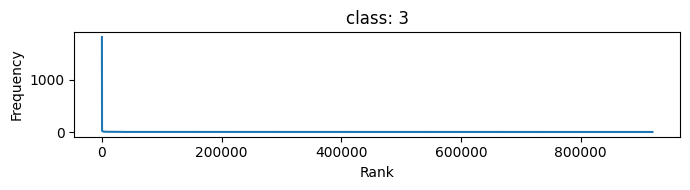

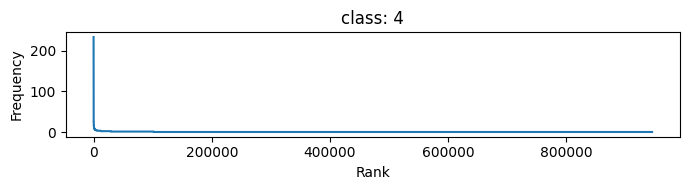

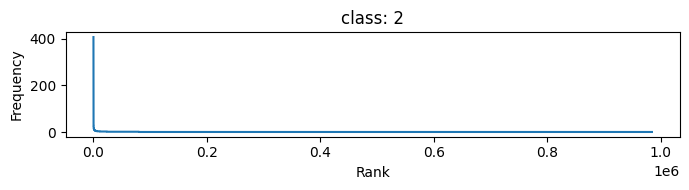

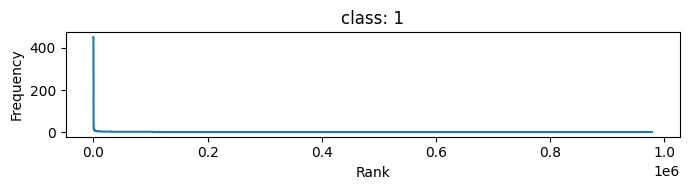

In [14]:
print("Discovery: the ngram frequency follows Long-tail distribution")
run_ngram_distribution_analyse(train_dt_text_collect,4)